# EDA and Feature Engineering Pipeline for NeuroShield

This notebook explores the diabetic dataset, analyzes missing values, creates visualizations, and then runs the cleaning and feature engineering pipeline step by step.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the raw data
df_raw = pd.read_csv('data/diabetic/diabetic_data.csv')
print(f"Raw dataset shape: {df_raw.shape}")


Raw dataset shape: (101766, 50)


In [3]:
# Basic exploration
print("=== First 5 rows ===")
display(df_raw.head())

print("\n=== Dataset info ===")
df_raw.info()

print("\n=== Summary statistics (numeric columns) ===")
display(df_raw.describe())

print("\n=== Summary statistics (categorical columns) ===")
categorical_cols = df_raw.select_dtypes(include=['object']).columns
display(df_raw[categorical_cols].describe())


=== First 5 rows ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



=== Dataset info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000



=== Summary statistics (categorical columns) ===


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


=== Missing values count ===


,Missing Count,Missing Percentage
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322



=== Count of '?' values (dataset's null marker) ===


,? Count,? Percentage
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


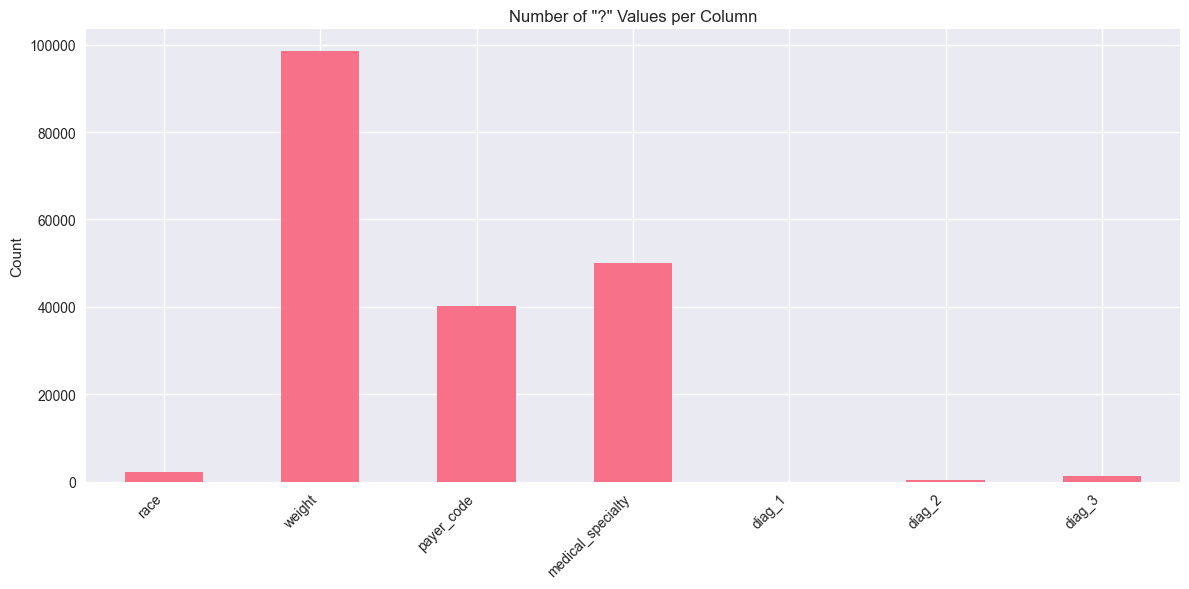

In [4]:
# Missing value analysis
print("=== Missing values count ===")
missing_count = df_raw.isnull().sum()
missing_percent = (missing_count / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percent})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

# Note: The dataset uses '?' as missing value marker, not NaN
print("\n=== Count of '?' values (dataset's null marker) ===")
question_mark_count = (df_raw == '?').sum()
question_mark_percent = (question_mark_count / len(df_raw)) * 100
question_mark_df = pd.DataFrame({'? Count': question_mark_count, '? Percentage': question_mark_percent})
display(question_mark_df[question_mark_df['? Count'] > 0].sort_values('? Count', ascending=False))

# Visualize missing values
plt.figure(figsize=(12, 6))
missing_to_plot = question_mark_df[question_mark_df['? Count'] > 0]
if len(missing_to_plot) > 0:
    missing_to_plot['? Count'].plot(kind='bar')
    plt.title('Number of "?" Values per Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No '?' values found.")


=== Visualizations ===


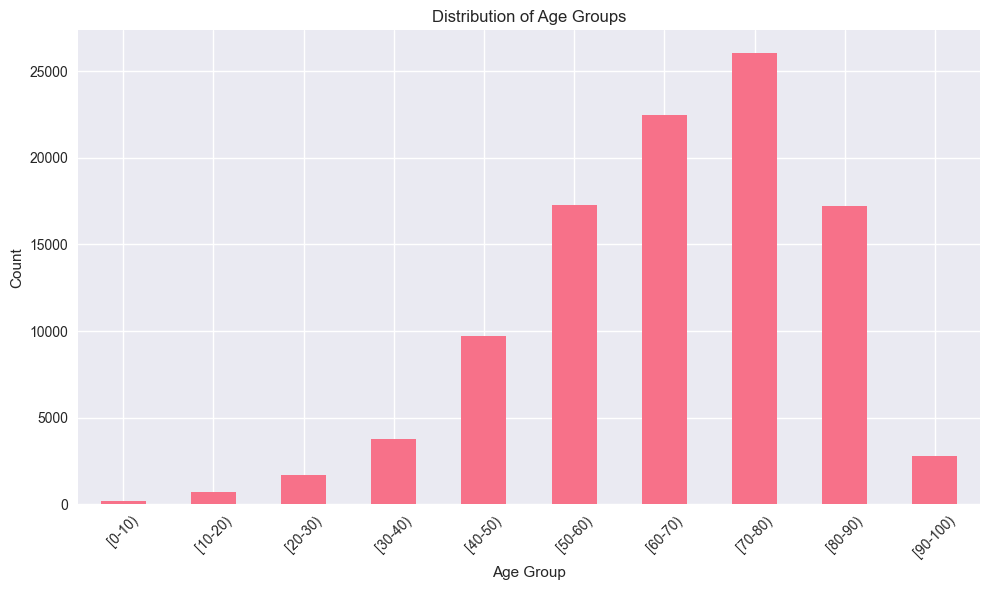

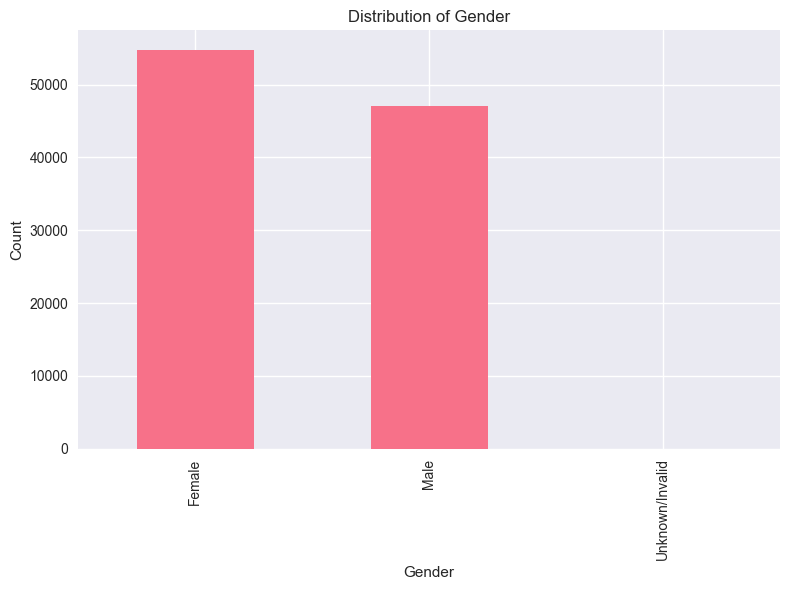

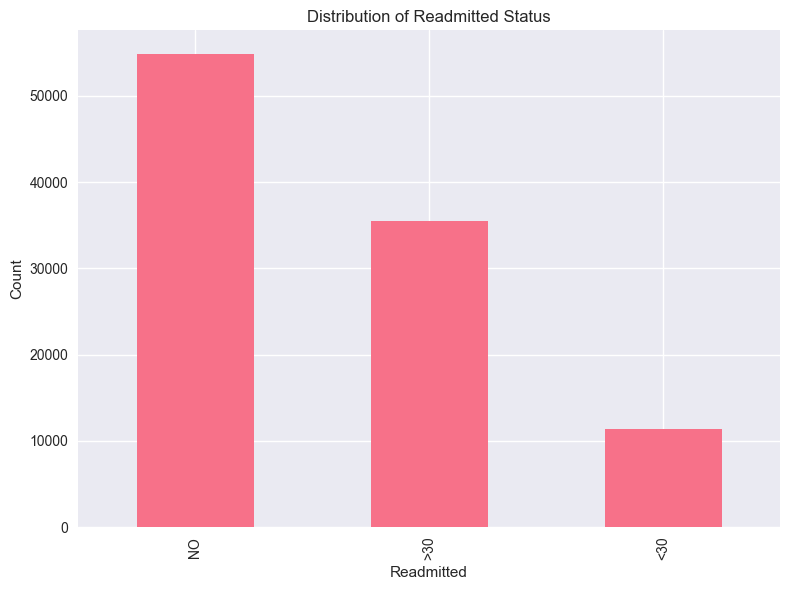

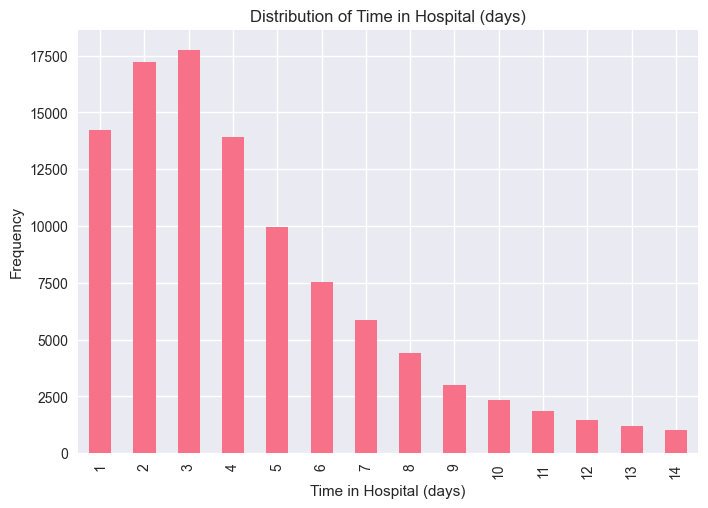

In [5]:
# Visualizations
print("=== Visualizations ===")

# 1. Age distribution (note: age is categorical)
plt.figure(figsize=(10, 6))
age_counts = df_raw['age'].value_counts().sort_index()
age_counts.plot(kind='bar')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Gender distribution
plt.figure(figsize=(8, 6))
gender_counts = df_raw['gender'].value_counts()
gender_counts.plot(kind='bar')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Readmitted distribution (our target)
plt.figure(figsize=(8, 6))
readmitted_counts = df_raw['readmitted'].value_counts()
readmitted_counts.plot(kind='bar')
plt.title('Distribution of Readmitted Status')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4. Time in hospital distribution
df_raw['time_in_hospital'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Time in Hospital (days)')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('Frequency')
plt.show()


In [6]:
# Import and run cleaning function
from features.clean import load_and_clean

print("=== Running data cleaning ===")
df_clean = load_and_clean()
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

# Show first few rows of cleaned data
display(df_clean.head())


=== Running data cleaning ===
[clean] Loaded  : 101,766 rows x 50 columns
[clean] Dropped  : ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
[clean] Null cells remaining : 0
[clean] Final shape          : (101766, 45)
Cleaned dataset shape: (101766, 45)
Missing values after cleaning: 0


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Import and run label function
from features.label import add_label

print("=== Adding label ===")
df_label = add_label(df_clean.copy())
print(f"Dataset with label shape: {df_label.shape}")
print(f"Label distribution:\n{df_label['label'].value_counts()}")

# Show first few rows with label
display(df_label[['readmitted', 'label']].head())


=== Adding label ===
[label] Positive rate (readmitted <30d) : 11.16%
[label] Raw counts:
label
0    90409
1    11357
Name: count, dtype: int64
Dataset with label shape: (101766, 46)
Label distribution:
label
0    90409
1    11357
Name: count, dtype: int64


,readmitted,label
0,NO,0
1,>30,0
2,NO,0
3,NO,0
4,NO,0


In [8]:
# Import and run CCI function
from features.cci import add_cci_feature

print("=== Adding CCI feature ===")
df_cci = add_cci_feature(df_label.copy())
print(f"Dataset with CCI shape: {df_cci.shape}")
print(f"CCI distribution:\n{df_cci['charlson_comorbidity_index'].value_counts().sort_index()}")

# Show first few rows with CCI
display(df_cci[['charlson_comorbidity_index']].head())


=== Adding CCI feature ===
[cci] CCI computed. Value counts:
charlson_comorbidity_index
1    42601
0    40150
2    11267
3     5878
8      936
6      570
7      191
9      173
Name: count, dtype: int64
Dataset with CCI shape: (101766, 47)
CCI distribution:
charlson_comorbidity_index
0    40150
1    42601
2    11267
3     5878
6      570
7      191
8      936
9      173
Name: count, dtype: int64


,charlson_comorbidity_index
0,2
1,1
2,0
3,2
4,8


In [9]:
from features.engineer import run_feature_pipeline

print("=== Applying feature engineering step by step ===")

df_features = run_feature_pipeline(df_cci.copy())

display(df_features.head())



=== Applying feature engineering step by step ===
[engineer] Applied: add_ip_admissions
[engineer] Applied: add_ed_visits
[engineer] Applied: add_medication_count
[engineer] Applied: add_length_of_stay
[engineer] Applied: add_medication_change_flag
[engineer] Applied: add_admission_acuity_flag
[engineer] Applied: add_high_utilizer_flag
[engineer] Applied: add_high_risk_medication_flag
[engineer] Applied: add_complex_discharge_flag
[engineer] Applied: add_behavioral_health_flag
[engineer] Applied: add_frailty_proxy
[engineer] Applied: add_no_show_proxy
[engineer] Applied: add_probabilistic_no_show
[engineer] Applied: encode_and_drop_features


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,race_Other,gender_Female,gender_Male,gender_Unknown/Invalid,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm
0,[0-10),6,25,1,1,41,0,1,0,0,...,0,1,0,0,0,0,1,0,1,0
1,[10-20),1,1,7,3,59,0,18,0,0,...,0,1,0,0,0,0,1,0,1,0
2,[20-30),1,1,7,2,11,5,13,2,0,...,0,1,0,0,0,0,1,0,1,0
3,[30-40),1,1,7,2,44,1,16,0,0,...,0,0,1,0,0,0,1,0,1,0
4,[40-50),1,1,7,1,51,0,8,0,0,...,0,0,1,0,0,0,1,0,1,0


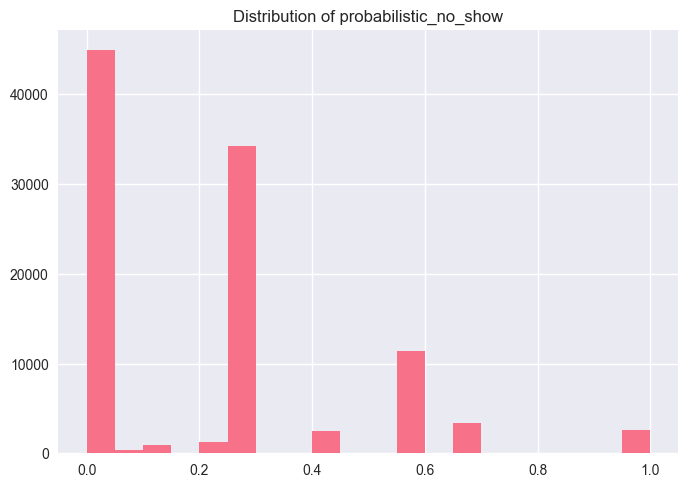

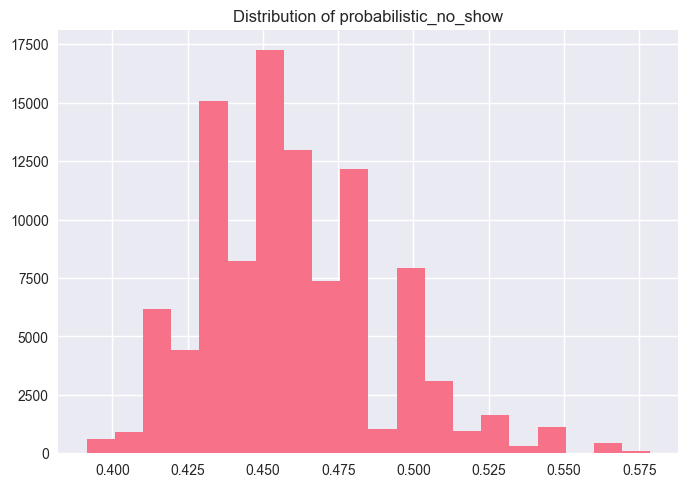

In [10]:
#Info of no_show_proxy and probabilistic_no_show features

df_features["no_show_proxy"].hist(bins=20)
plt.title("Distribution of probabilistic_no_show")
plt.show()
# cut around 0.25

df_features["probabilistic_no_show"].hist(bins=20)
plt.title("Distribution of probabilistic_no_show")
plt.show()
# cut around 0.450


In [11]:
# build_features function automatically calls load_and_clean(), add_label(df), add_cci_feature(df), df = run_feature_pipeline(df)
from features.build_features import build_features

df_build_features = build_features(df_features, Path("data/diabetic/notebook_features.csv"), 101_766)

display(df_build_features.head())


[build] Dropped source columns: ['readmitted', 'number_inpatient', 'number_emergency', 'num_medications', 'time_in_hospital', 'change', 'admission_type_id', 'number_diagnoses', 'diag_1', 'diag_2', 'diag_3', 'age']

  WEEK 2 VERIFICATION GATE
  [PASS] Zero null values                    0 nulls found
  [PASS] Row count ~101,766                  101,766 rows
  [PASS] Positive rate ~11%                  11.16%

[build] Saved -> data/diabetic/notebook_features.csv  (101,766 rows x 35 cols)


,discharge_disposition_id,admission_source_id,num_lab_procedures,num_procedures,number_outpatient,diabetesMed,label,charlson_comorbidity_index,ip_admissions_365d_prior,ed_visits_90d_prior,...,race_Other,gender_Female,gender_Male,gender_Unknown/Invalid,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm
0,25,1,41,0,0,0,0,2,0,0,...,0,1,0,0,0,0,1,0,1,0
1,1,7,59,0,0,1,0,1,0,0,...,0,1,0,0,0,0,1,0,1,0
2,1,7,11,5,2,1,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0
3,1,7,44,1,0,1,0,2,0,0,...,0,0,1,0,0,0,1,0,1,0
4,1,7,51,0,0,1,0,8,0,0,...,0,0,1,0,0,0,1,0,1,0


In [12]:
# Compare original and processed dataframes
print("=== Comparison: Original vs Processed ===")
print()
print("1. Shape comparison:")
print(f"   Original: {df_raw.shape}")
print(f"   Processed: {df_build_features.shape}")
print()
print("2. Columns comparison:")
print(f"   Original columns ({len(df_raw.columns)}): {list(df_raw.columns)}")
print(f"   Processed columns ({len(df_build_features.columns)}): {list(df_build_features.columns)}")
print()
print("3. Missing values comparison:")
print(f"   Original missing values (as '?'): {(df_raw == '?').sum().sum()}")
print(f"   Processed missing values: {df_build_features.isnull().sum().sum()}")
print()
print("4. Data types comparison:")
print("   Original data types:")
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f"      {dtype}: {count}")
print("   Processed data types:")
for dtype, count in df_build_features.dtypes.value_counts().items():
    print(f"      {dtype}: {count}")
print()
print("5. Label distribution in processed data:")
if 'label' in df_build_features.columns:
    print(df_build_features['label'].value_counts())
    print(f"   Positive rate: {df_build_features['label'].mean():.2%}")
else:
    print("Label column not found in processed data.")



=== Comparison: Original vs Processed ===

1. Shape comparison:
   Original: (101766, 50)
   Processed: (101766, 35)

2. Columns comparison:
   Original columns (50): ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
   Processed co

In [13]:
df_features = pd.read_csv('data/diabetic/features.csv')
assert 'no_show_proxy' in df_features.columns
assert 'probabilistic_no_show' in df_features.columns
assert df_features[['no_show_proxy', 'probabilistic_no_show']].isnull().sum().sum() == 0
print("Both new features confirmed present with zero nulls.")
print(df_features[['no_show_proxy', 'probabilistic_no_show']].describe())

Both new features confirmed present with zero nulls.
       no_show_proxy  probabilistic_no_show
count  101766.000000          101766.000000
mean        0.230842               0.459783
std         0.252409               0.029624
min         0.000000               0.391485
25%         0.000000               0.433680
50%         0.300000               0.452459
75%         0.300000               0.478961
max         1.000000               0.578644


In [14]:
from models.train_balanced_importance import (
    load_and_validate,
    temporal_split,
    tune_decision_tree,
    tune_xgboost
)


df, feature_cols = load_and_validate("data/diabetic/features_balanced_importance.csv")

train_df, test_df = temporal_split(df, 0.8)

X_train = train_df[feature_cols]
y_train = train_df["label"]
w_train = train_df["sample_weight"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-08 13:08:31,524 [INFO] Loading features from data/diabetic/features_balanced_importance.csv
2026-04-08 13:08:31,674 [INFO] Loaded 101,766 rows, 36 columns
2026-04-08 13:08:31,678 [INFO] Positive label rate: 0.4609
2026-04-08 13:08:31,688 [INFO] Temporal split: train=81,412 rows | test=20,354 rows


In [15]:
model_dt, auc_dt, y_prob_dt, y_pred_dt = tune_decision_tree(
    X_train, y_train, w_train, X_test, y_test
)

model_xgb, auc_xgb, y_prob_xgb, y_pred_xgb = tune_xgboost(
    X_train, y_train, w_train, X_test, y_test
)

2026-04-08 13:08:31,703 [INFO] --- Tuning DecisionTreeClassifier ---
2026-04-08 13:08:44,768 [INFO] [DT] Best params: {'max_depth': 7, 'min_samples_leaf': 50}
2026-04-08 13:08:44,770 [INFO] [DT] CV AUC: 0.6568 | Test AUC: 0.6911
2026-04-08 13:08:44,771 [INFO] --- Tuning XGBClassifier ---


/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:45] WARN

2026-04-08 13:08:49,773 [INFO] [XGB] Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
2026-04-08 13:08:49,774 [INFO] [XGB] CV AUC: 0.6781 | Test AUC: 0.7063


In [16]:
from models.train_balanced_importance import run_training_pipeline

results = run_training_pipeline()

results["auc_xgb"]

2026-04-08 13:08:49,792 [INFO] Loading features from data/diabetic/features_balanced_importance.csv
2026-04-08 13:08:50,007 [INFO] Loaded 101,766 rows, 36 columns
2026-04-08 13:08:50,014 [INFO] Positive label rate: 0.4609
2026-04-08 13:08:50,024 [INFO] Temporal split: train=81,412 rows | test=20,354 rows
2026-04-08 13:08:50,032 [INFO] --- Tuning DecisionTreeClassifier ---
2026-04-08 13:08:52,892 [INFO] [DT] Best params: {'max_depth': 7, 'min_samples_leaf': 50}
2026-04-08 13:08:52,895 [INFO] [DT] CV AUC: 0.6568 | Test AUC: 0.6911
2026-04-08 13:08:52,895 [INFO] --- Tuning XGBClassifier ---


/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:08:53] WARN

2026-04-08 13:08:57,320 [INFO] [XGB] Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
2026-04-08 13:08:57,320 [INFO] [XGB] CV AUC: 0.6781 | Test AUC: 0.7063


0.7062711087865874

In [17]:
from models.shap_utils import build_shap_explainer, get_patient_explanation

explainer = build_shap_explainer(results["model_xgb"])

sample = results["X_test"].sample(3)

for _, row in sample.iterrows():
    patient = row.to_frame().T
    print(get_patient_explanation(explainer, patient))

['Prior inpatient admissions (last 365 days) (increased risk)', 'High historical utilization of hospital resources (increased risk)', 'Length of hospital stay (increased risk)']
['Historical missed appointment pattern (increased risk)', 'Prior emergency visits (last 90 days) (increased risk)', 'Prior inpatient admissions (last 365 days) (decreased risk)']
['Admission source (decreased risk)', 'Prior inpatient admissions (last 365 days) (decreased risk)', 'Historical missed appointment pattern (increased risk)']


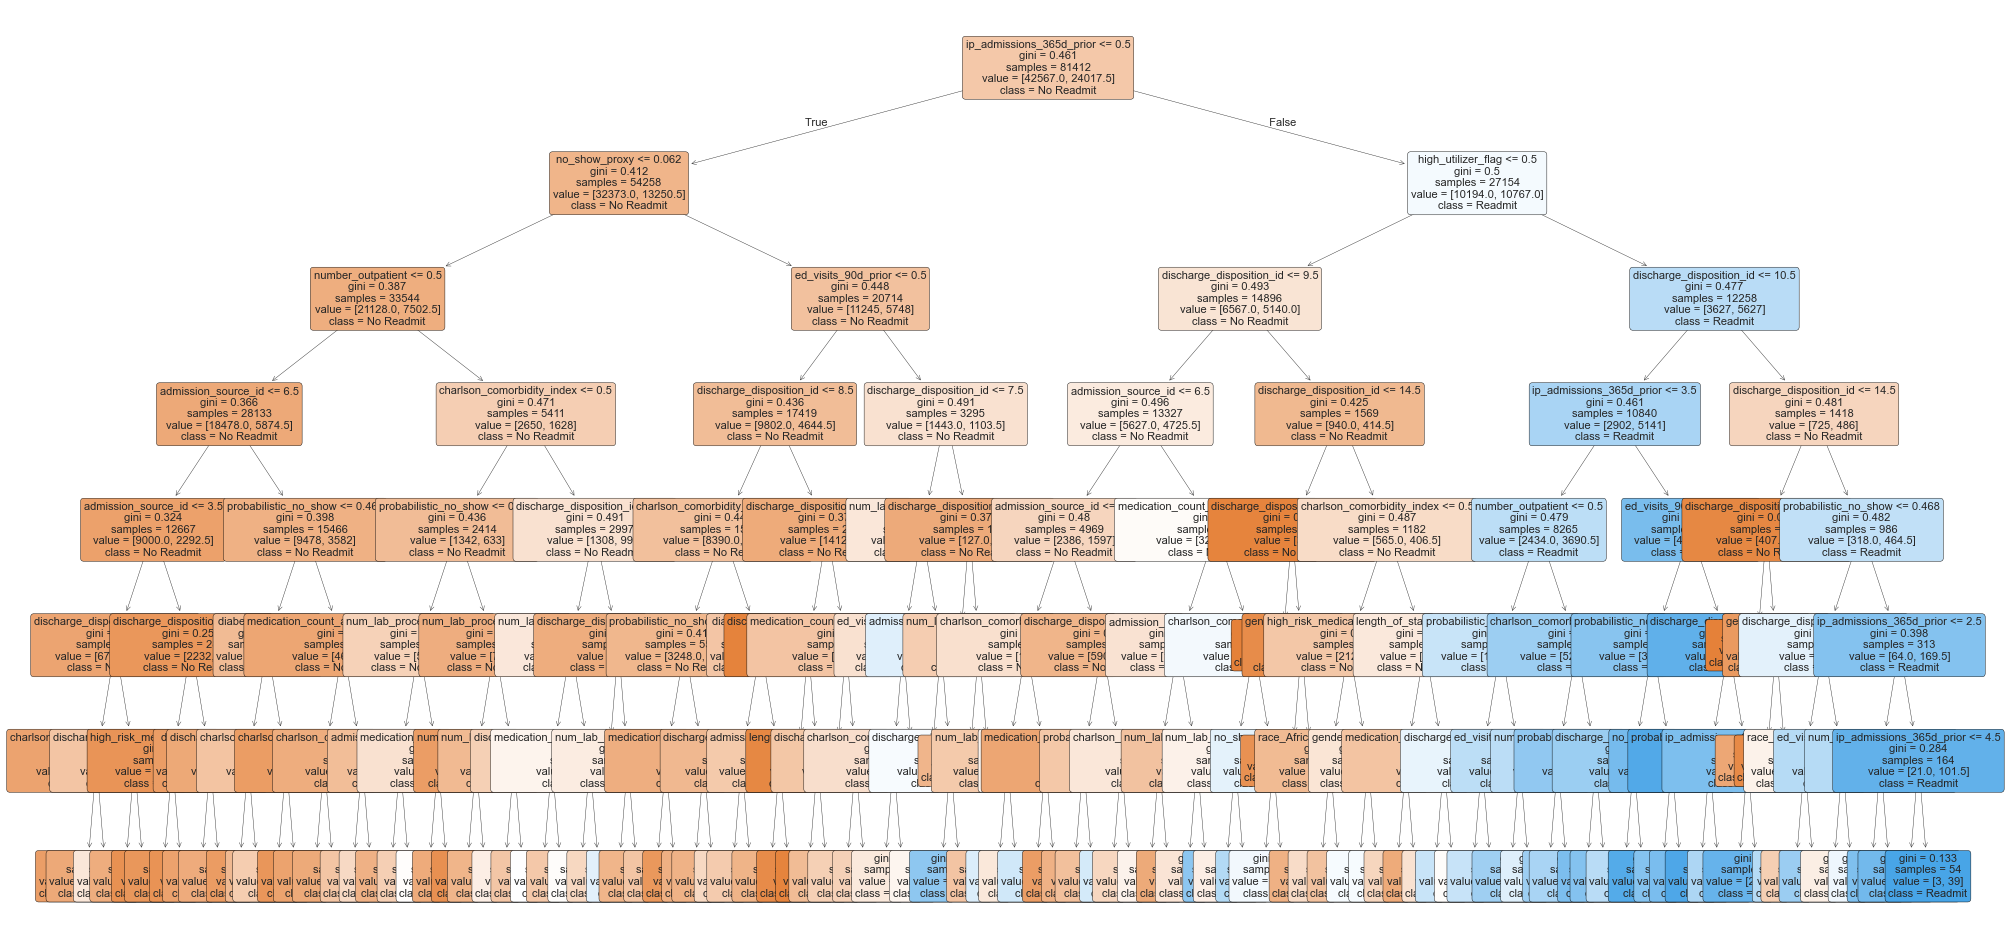

In [18]:
from sklearn import tree
import matplotlib.pyplot as plt


dt_model = results["model_dt"]

plt.figure(figsize=(24, 12))
tree.plot_tree(
    dt_model,
    feature_names=results["X_test"].columns,
    class_names=["No Readmit", "Readmit"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

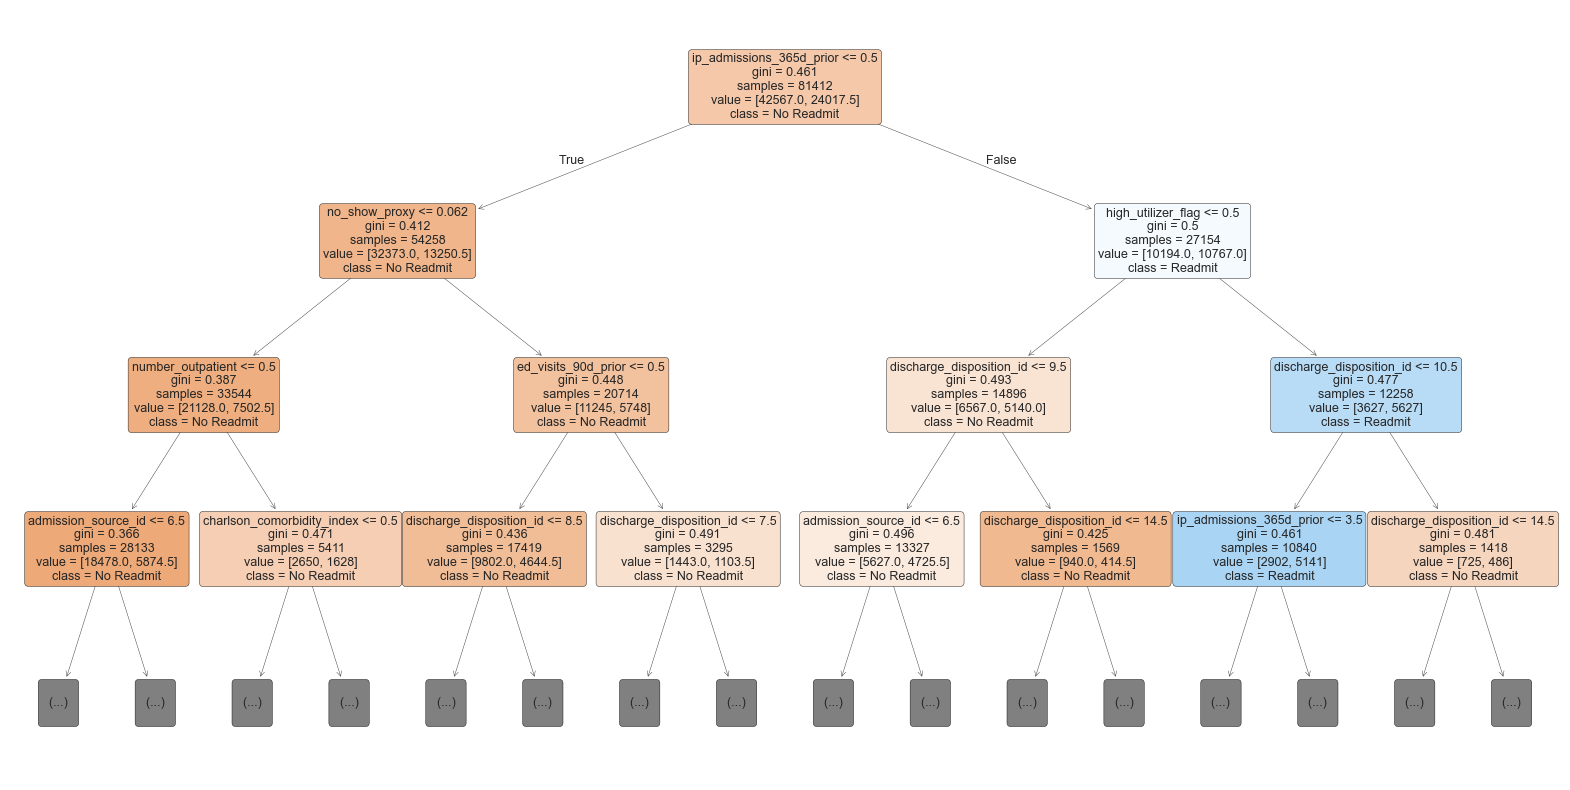

In [19]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt_model,
    feature_names=results["X_test"].columns,
    class_names=["No Readmit", "Readmit"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.show()

In [20]:
from models.driver_extractor import extract_drivers_for_batch

dt_model = results["model_dt"]
feature_names = dt_model.feature_names_in_.tolist()
X_test = results["X_test"][feature_names]

driver_df = extract_drivers_for_batch(
    model=dt_model,
    feature_names=feature_names,
    X=X_test,
    n_drivers=3,
)

dt_probs = dt_model.predict_proba(X_test)[:, 1]

final_dt_output = X_test.copy()
final_dt_output["predicted_prob_dt"] = dt_probs
final_dt_output["risk_score_dt"] = (dt_probs * 100).round(1)
final_dt_output = final_dt_output.join(driver_df)

final_dt_output[["risk_score_dt", "driver_1", "driver_2", "driver_3"]].head()

/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/umair/Documents/Denovonet/neuroshield/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/umair/Documents/Denovonet/neuroshield/.ve

,risk_score_dt,driver_1,driver_2,driver_3
81412,35.4,Discharge disposition ID: 1 (indicates where t...,Number of lab procedures during stay: 10 (more...,Comorbidity burden score: 2 (higher score = mo...
81413,37.1,Admission source ID: 1 (indicates where the pa...,Prescribed diabetes medication: Yes (active ph...,Comorbidity burden score: 1 (higher score = mo...
81414,24.0,Comorbidity burden score: 2 (higher score = mo...,Discharge disposition ID: 1 (indicates where t...,Admission source ID: 1 (indicates where the pa...
81415,35.0,Prescribed diabetes medication: Yes (active ph...,Predicted likelihood of missing follow-up appo...,Comorbidity burden score: 0 (higher score = mo...
81416,18.8,Comorbidity burden score: 0 (higher score = mo...,Discharge disposition ID: 1 (indicates where t...,Admission source ID: 1 (indicates where the pa...


In [21]:
from sklearn.metrics import accuracy_score

# Decision Tree predictions
dt_preds = results["model_dt"].predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

# XGBoost predictions
xgb_preds = results["model_xgb"].predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print("Decision Tree Accuracy:", dt_acc)
print("XGBoost Accuracy:", xgb_acc)

Decision Tree Accuracy: 0.6653237692836789
XGBoost Accuracy: 0.6708755035865186


In [22]:
from sklearn.metrics import precision_score, recall_score

print("XGB Precision:", precision_score(y_test, xgb_preds))
print("XGB Recall:", recall_score(y_test, xgb_preds))

XGB Precision: 0.6233200145296041
XGB Recall: 0.4259649993794216


In [3]:
import pandas as pd

# Load CSV
df = pd.read_csv("data/output/patient_worklist_2026-04-22.csv")

# Create a temporary column for grouping (lowercase only for logic)
df['_risk_band_clean'] = df['risk_band'].str.lower().str.strip()

# Sample 10 from each group
sampled_df = df.groupby('_risk_band_clean', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 20), random_state=42)
)

# Drop the helper column
sampled_df = sampled_df.drop(columns=['_risk_band_clean'])

# Reset index
sampled_df = sampled_df.reset_index(drop=True)

# Overwrite CSV
sampled_df.to_csv("data/output/patient_worklist_2026-04-22.csv", index=False)

print("Done! Original casing preserved ✅")

Done! Original casing preserved ✅


/var/folders/qw/zjnbjhl91jl13dsh42b0sfkr0000gn/T/ipykernel_56652/3126093875.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('_risk_band_clean', group_keys=False).apply(


In [1]:
import pandas as pd
import random

# Load CSV
df = pd.read_csv("data/output/patient_worklist_2026-04-29.csv")

# Clean column for grouping
df['_risk_band_clean'] = df['risk_band'].str.lower().str.strip()

def sample_random(group):
    k = random.randint(10, 30)  # pick random number between 10–30
    k = min(len(group), k)      # don't exceed group size
    return group.sample(n=k, random_state=42)

# Apply sampling
sampled_df = df.groupby('_risk_band_clean', group_keys=False).apply(sample_random)

# Drop helper column
sampled_df = sampled_df.drop(columns=['_risk_band_clean']).reset_index(drop=True)

# Save
sampled_df.to_csv("data/output/patient_worklist_2026-04-29.csv", index=False)

print("Done! Random sampling per category (10-30) ✅")

Done! Random sampling per category (10-30) ✅


/var/folders/qw/zjnbjhl91jl13dsh42b0sfkr0000gn/T/ipykernel_63271/1687913298.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('_risk_band_clean', group_keys=False).apply(sample_random)


In [ ]:
. .venv/bin/activate && python outputs/risk_registry.py --worklist-csv data/output/patient_worklist_2026-04-22.csv --model-version readmission-dt-balanced-importance
